In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/sales_data.csv", encoding='latin1')

In [3]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 166.7 KB


In [5]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='str')

In [10]:
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [11]:
df['MONTH'] = df['Sale_Date'].dt.month

In [12]:
df['YEAR'] = df['Sale_Date'].dt.year

In [13]:
total_sales = df['Sales_Amount'].sum()

print(total_sales)

5019265.2299999995


In [14]:
top_products = df.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)

print(top_products)

Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64


In [15]:
monthly_sales = df.groupby('MONTH')['Sales_Amount'].sum()

print(monthly_sales)

MONTH
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Sales_Amount, dtype: float64


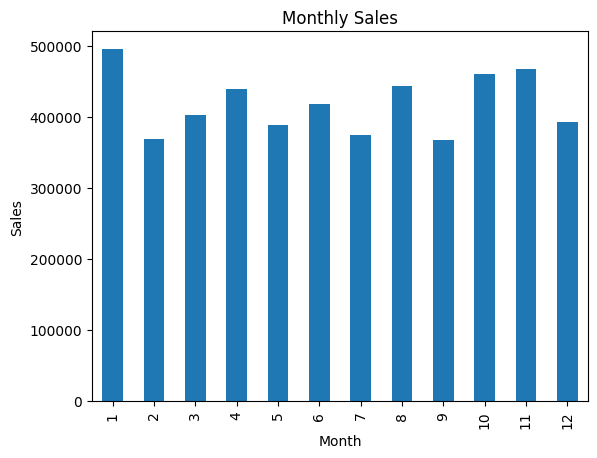

In [16]:
monthly_sales.plot(kind='bar')

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [17]:
df.to_csv("../outputs/cleaned_inventory_data.csv", index=False)